# HW_5. Study an integral
## Roman Branovets, Skoltech, 2025

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
!pip install mpi4py

In [12]:
def func(x):
    f = 5*x-0.5*np.exp(x)+x**(1.5)
    return f

1. Compute the value analytically

In [13]:
antider = lambda x: -np.exp(x)/2 + 2/5*x**2.5+2.5*x**2
a_val = antider(2) - antider(0)
print(a_val)

9.068213650331627


2. Compute the integral using trapezoidal rule

In [14]:
start = 0
stop = 2
k = 1000
x = np.linspace(start, stop, k)
fx = np.vectorize(lambda x: 5*x-0.5*np.exp(x)+x**(1.5))(x)
res = 0
for i in range(1, len(x)):
    res += (fx[i-1] + fx[i])/2 * (x[i] - x[i-1])
print(res)

9.068213287308904


3. Parallelize using MPI. You should be able to choose any number of MPI processes regardless of the number of discretization points.

In [15]:
%%writefile integral.py
start = 0
stop = 2
k = 1000

from mpi4py import MPI
import numpy as np

comm1 = MPI.COMM_WORLD
rank1 = comm1.Get_rank()
size1 = comm1.Get_size()
active = min(size1, k)
if rank1 < active:
    color = 0
else:
    color = MPI.UNDEFINED
comm = comm1.Split(color=color, key=rank1)
if comm == MPI.COMM_NULL:
    MPI.Finalize()
    raise SystemExit()

rank = comm.Get_rank()
size = comm.Get_size()

x = np.linspace(start + stop/size * rank, stop/size * (rank+1), k // size
                + (1 if rank < k % size else 0), dtype=np.double)
fx = np.vectorize(lambda x: 5*x-0.5*np.exp(x)+x**(1.5))(x)
res = 0
reduced_res = None
for i in range(1, len(x)):
    res += (fx[i-1] + fx[i])/2 * (x[i] - x[i-1])
if rank == 0:
    reduced_res = np.empty(1, dtype=np.double)
res = np.array(res, dtype=np.double)
comm.Reduce([res, 1, MPI.DOUBLE], [reduced_res, 1, MPI.DOUBLE], op=MPI.SUM, root=0)
if rank == 0:
    print(reduced_res[0])
MPI.Finalize()

Overwriting integral.py


In [16]:
!mpirun -n 4 --allow-run-as-root --oversubscribe python integral.py

9.068213285111806


4. Plot the speedup vs number of processors

In [17]:
%%writefile time_integral.py
#for computing without printing
start = 0
stop = 2
k = 1000

from mpi4py import MPI
import numpy as np

comm1 = MPI.COMM_WORLD
rank1 = comm1.Get_rank()
size1 = comm1.Get_size()
active = min(size1, k)
if rank1 < active:
    color = 0
else:
    color = MPI.UNDEFINED
comm = comm1.Split(color=color, key=rank1)
if comm == MPI.COMM_NULL:
    MPI.Finalize()
    raise SystemExit()

rank = comm.Get_rank()
size = comm.Get_size()

t0 = MPI.Wtime()
x = np.linspace(start + stop/size * rank, stop/size * (rank+1), k // size
                + (1 if rank < k % size else 0), dtype=np.double)
fx = np.vectorize(lambda x: 5*x-0.5*np.exp(x)+x**(1.5))(x)
res = 0
reduced_res = None
for i in range(1, len(x)):
    res += (fx[i-1] + fx[i])/2 * (x[i] - x[i-1])
if rank == 0:
    reduced_res = np.empty(1, dtype=np.double)
res = np.array(res, dtype=np.double)
comm.Reduce([res, 1, MPI.DOUBLE], [reduced_res, 1, MPI.DOUBLE], op=MPI.SUM, root=0)
t1 = MPI.Wtime()
time = t1-t0
time = np.array(time, dtype=np.double)
rtime = None
if rank == 0:
    rtime = np.empty(1, dtype=np.double)
comm.Reduce([time, 1, MPI.DOUBLE], [rtime, 1, MPI.DOUBLE], op=MPI.MAX, root=0)
if rank == 0:
    with open("times.txt", "a") as ftime:
        ftime.write(f"{size} {rtime[0]}\n")
MPI.Finalize()

Overwriting time_integral.py


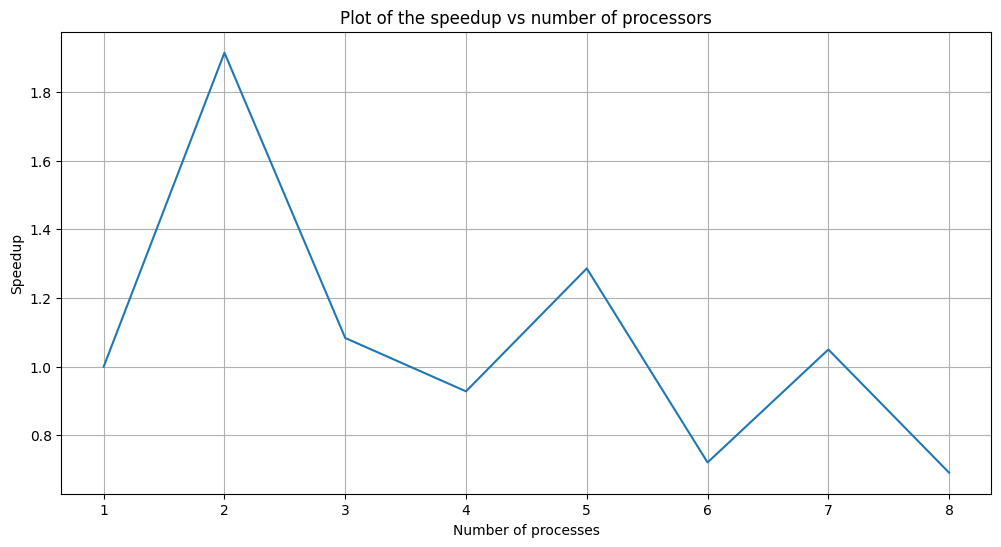

In [18]:
!rm -f times.txt
for i in range(1,9):
    !mpirun -n {i} --allow-run-as-root --oversubscribe python time_integral.py
datatime = np.loadtxt("times.txt")
procs = datatime[:, 0].astype(int)
times = datatime[0, 1]/datatime[:, 1]
plt.figure(figsize = (12,6))
plt.plot(procs, times)
plt.title('Plot of the speedup vs number of processors')
plt.xlabel('Number of processes')
plt.ylabel('Speedup')
plt.grid()
plt.show()

5. Plot integration error vs the discretization size

In [30]:
%%writefile error_integral.py
import numpy as np
import matplotlib.pyplot as plt
from mpi4py import MPI

start = 0
stop = 2
error = np.empty(10000)
antider = lambda x: -np.exp(x)/2 + 2/5*x**2.5+2.5*x**2
a_val = antider(2) - antider(0)
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
for k in range(50, 10000,20):
    x = np.linspace(start + stop/size * rank, stop/size * (rank+1), k // size
                    + (1 if rank < k % size else 0), dtype=np.double)
    fx = np.vectorize(lambda x: 5*x-0.5*np.exp(x)+x**(1.5))(x)
    res = 0
    reduced_res = None
    for i in range(1, len(x)):
        res += (fx[i-1] + fx[i])/2 * (x[i] - x[i-1])
    if rank == 0:
        reduced_res = np.empty(1, dtype=np.double)
    res = np.array(res, dtype=np.double)
    comm.Reduce([res, 1, MPI.DOUBLE], [reduced_res, 1, MPI.DOUBLE], op=MPI.SUM, root=0)
    if rank == 0:
        error[k] = abs(reduced_res[0] - a_val)
if rank == 0:
    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(50,10000,20) ,error[50::20])
    plt.title('Integration error vs the discretization size')
    plt.xlabel('Discretization size')
    plt.ylabel('Integration error')
    plt.grid()
    plt.savefig("error_plot.png")
MPI.Finalize()

Overwriting error_integral.py


In [31]:
!mpirun -n 2 --allow-run-as-root --oversubscribe python error_integral.py

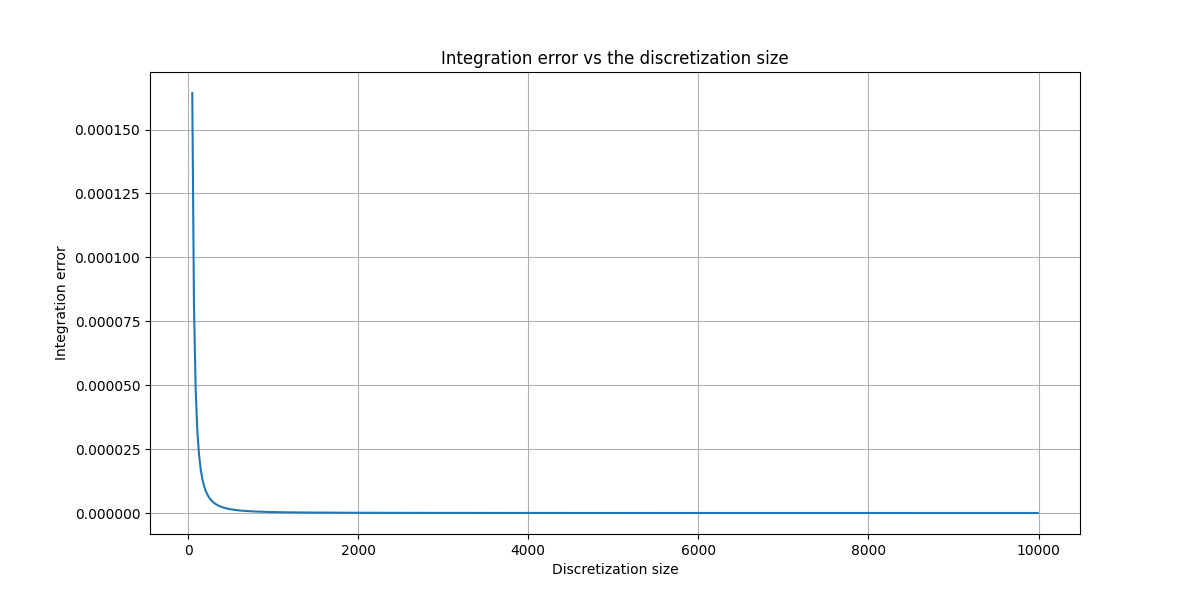

In [32]:
from IPython.display import Image
Image("error_plot.png")